In [1]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
from analysis import Analysis
import nafflib

PyHEADTAIL v1.16.5


# Diagnostic tool

In [2]:
def show_beam(analysis, turn=0):
    N_mon = analysis.n_monitors
    fig, axs=plt.subplots(2, figsize=(20,12))
    axs[0].plot(np.mean(analysis.x, axis=0)[N_mon*turn:N_mon*(turn+1)], c='b')
    axs[0].plot((np.mean(analysis.x, axis=0)
                 +np.std(analysis.x, axis=0))[N_mon*turn:N_mon*(turn+1)], c='b', ls='--')
    axs[0].plot((np.mean(analysis.x, axis=0)
                 -np.std(analysis.x, axis=0))[N_mon*turn:N_mon*(turn+1)], c='b', ls='--')
        
    axs[0].plot(analysis.x_pipe + analysis.x_length/2, c='k')
    axs[0].plot(analysis.x_pipe - analysis.x_length/2, c='k')
    axs[0].plot(analysis.x0, c='r')
    axs[0].plot(analysis.x0 + analysis.sigma_x, c='r', ls='--')
    axs[0].plot(analysis.x0 - analysis.sigma_x, c='r', ls='--')

    
    axs[1].plot(np.mean(analysis.y, axis=0)[N_mon*turn:N_mon*(turn+1)], c='b')
    axs[1].plot((np.mean(analysis.y, axis=0)
                 +np.std(analysis.y, axis=0))[N_mon*turn:N_mon*(turn+1)], c='b', ls='--')
    axs[1].plot((np.mean(analysis.y, axis=0)
                 -np.std(analysis.y, axis=0))[N_mon*turn:N_mon*(turn+1)], c='b', ls='--')
    axs[1].plot(analysis.y_pipe + analysis.y_length/2, c='k')
    axs[1].plot(analysis.y_pipe - analysis.y_length/2, c='k')
    axs[1].plot(analysis.y0, c='r')
    axs[1].plot(analysis.y0 + analysis.sigma_y, c='r', ls='--')
    axs[1].plot(analysis.y0 - analysis.sigma_y, c='r', ls='--')

    axs[0].set_ylabel('1 sigma x beam in pipe')
    axs[1].set_ylabel('1 sigma y beam in pipe')
    plt.show()

def plot_fft_centroid(x):
    x = np.mean(x, axis=0)
    N = len(x)
    x = x - np.mean(x)
    window = np.hanning(N)
    x = x * window
    fft_values = np.fft.rfft(x)
    frequencies = np.fft.rfftfreq(N) * 10
    amplitude = np.abs(fft_values)
    
    fig, ax = plt.subplots(1, figsize=(10,2))
    ax.plot(frequencies, amplitude)
    ax.set_xlim(4.25, 4.5)
    ax.axvline(x=4.47, color='red', label='Bare tune')
    ax.legend()
    ax.set_xlabel('Tune')
    ax.set_ylabel('Relative amplitude')

    return frequencies, amplitude/np.sum(amplitude)

# No SC

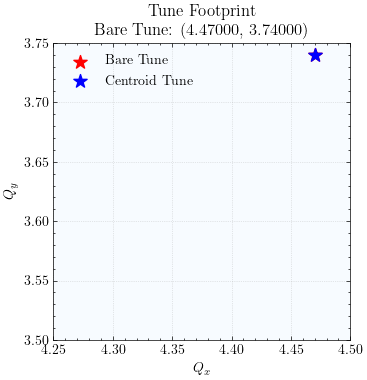

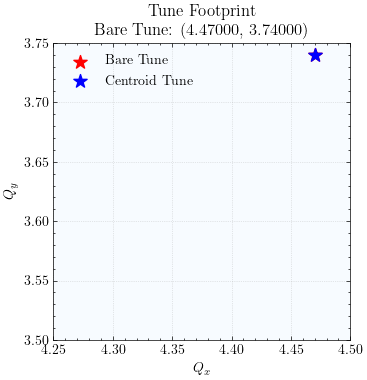

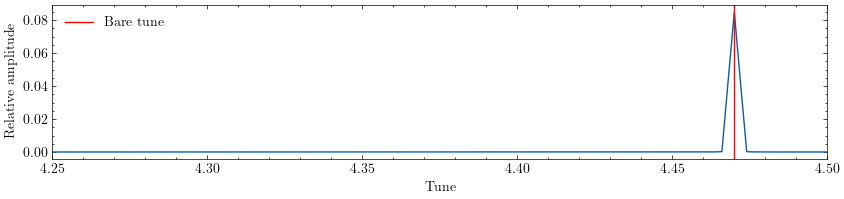

In [3]:
a = Analysis('data/no_sc')
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=1)
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=2)
f1, a1 = plot_fft_centroid(a.x)

# Direct SC

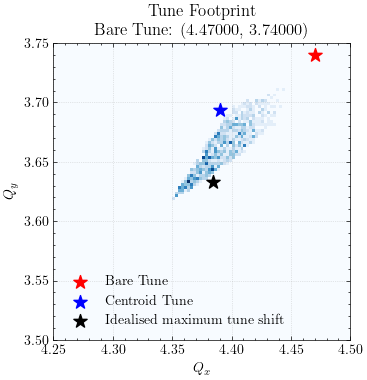

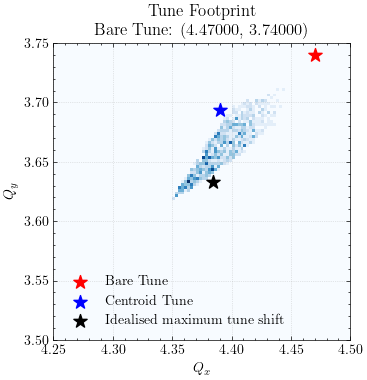

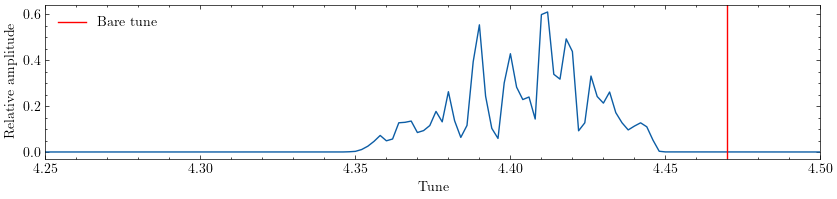

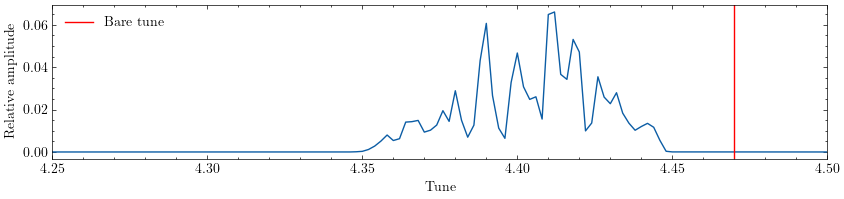

In [44]:
a = Analysis('data/direct_sc')
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=1)
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=0)
f2, a2 = plot_fft_centroid(a.x)
f2, a2 = plot_fft_centroid(a.px)

# Indirect SC

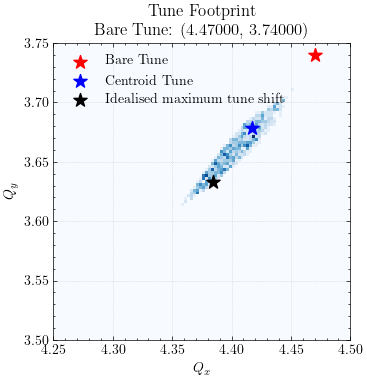

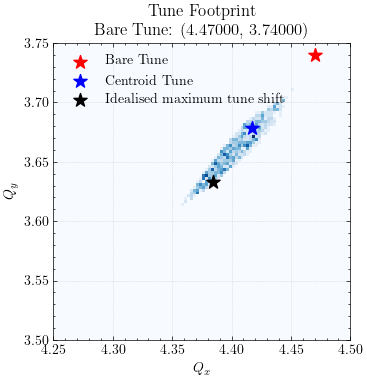

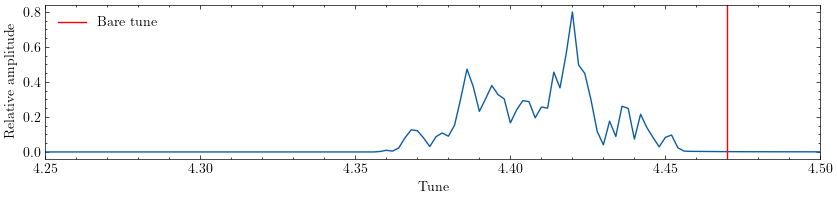

In [5]:
a = Analysis('data/indirect_sc')
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=1)
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=2)
f3, a3 = plot_fft_centroid(a.x)

Text(0, 0.5, 'Relative Amplitude')

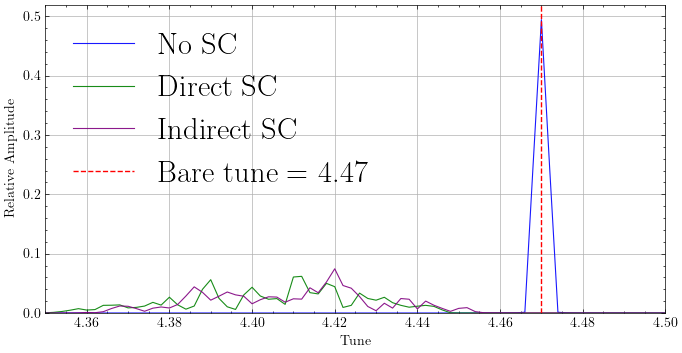

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(f1,a1, label='No SC', lw='.8', c='b', alpha=0.9)
ax.plot(f2,a2, label='Direct SC', lw='.8', c='g', alpha=0.9)
ax.plot(f3,a3, label='Indirect SC', lw='.8', c='purple', alpha=0.9)
ax.set_xlim(4.35,4.5)
ax.axvline(x=4.47, color='red', ls='--', label='Bare tune = 4.47')
ax.legend(fontsize=22)
ax.set_ylim(0)
ax.grid()
ax.set_xlabel('Tune')
ax.set_ylabel('Relative Amplitude')

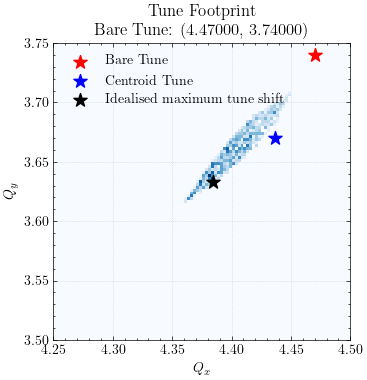

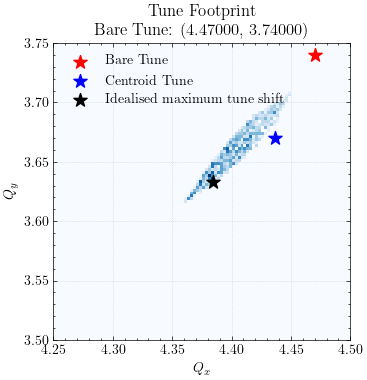

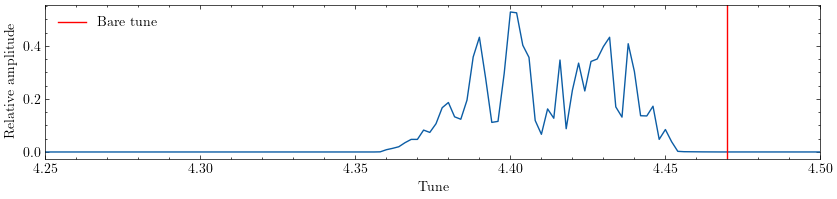

In [42]:
"""a = Analysis('data/no_sc_offset')
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=1)
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=2)
f1, a1 = plot_fft_centroid(a.x)

a = Analysis('data/direct_sc_offset')
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=1)
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=2)
f2, a2 = plot_fft_centroid(a.x)"""

a = Analysis('data/indirect_sc_offset')
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=1)
a.tune_histogram(x_lims=(4.25,4.5), y_lims=(3.5,3.75), centroid=True, half=2)
f3, a3 = plot_fft_centroid(a.x)

Text(0, 0.5, 'Relative Amplitude')

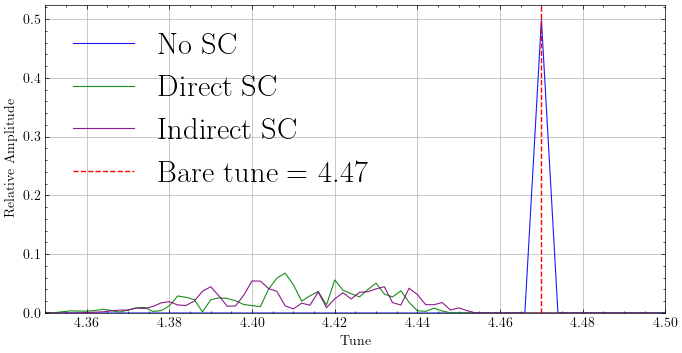

In [13]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(f1,a1, label='No SC', lw='.8', c='b', alpha=0.9)
ax.plot(f2,a2, label='Direct SC', lw='.8', c='g', alpha=0.9)
ax.plot(f3,a3, label='Indirect SC', lw='.8', c='purple', alpha=0.9)
ax.set_xlim(4.35,4.5)
ax.axvline(x=4.47, color='red', ls='--', label='Bare tune = 4.47')
ax.legend(fontsize=22)
ax.set_ylim(0)
ax.grid()
ax.set_xlabel('Tune')
ax.set_ylabel('Relative Amplitude')

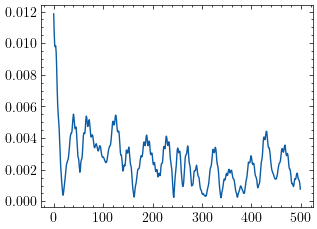

In [43]:
x_centroid = np.mean(a.x, axis=0)

x_tbt = []
for i in range(0,500):
    x = x_centroid[10*i:10*(i+1)]
    x_tbt.append(np.sqrt(np.sum(x**2)))
    #x_tbt.append(np.max(x))
plt.plot(range(0,500), x_tbt)
plt.show()
